In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Python environment is working!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python environment is working!
Pandas version: 3.0.6
NumPy version: 2.4.6


In [16]:
raw_df = pd.read_csv("../data/raw/medical_insurance_with_smoker.csv")

print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])


Rows: 1338
Columns: 7


In [17]:
# Create missing values for demonstration purposes

raw_df.loc[raw_df.sample(8, random_state=10).index, "bmi"] = np.nan
raw_df.loc[raw_df.sample(5, random_state=20).index, "gender"] = np.nan
raw_df.loc[raw_df.sample(5, random_state=30).index, "region"] = np.nan
raw_df.loc[raw_df.sample(5, random_state=40).index, "smoker"] = np.nan
raw_df.loc[raw_df.sample(5, random_state=50).index, "expenses"] = np.nan

print(raw_df.isnull().sum())

age         0
gender      5
bmi         8
children    0
region      5
expenses    5
smoker      5
dtype: int64


In [18]:
# Create duplicate rows for demonstration

duplicates = raw_df.sample(8, random_state=100)

raw_df = pd.concat([raw_df, duplicates], ignore_index=True)

print("New shape:", raw_df.shape)
print("Duplicate rows:", raw_df.duplicated().sum())

New shape: (1346, 7)
Duplicate rows: 9


In [19]:
# Introduce inconsistent categorical values

# Gender inconsistencies
gender_indices = raw_df[raw_df["gender"].notna()].sample(6, random_state=200).index

raw_df.loc[gender_indices[:2], "gender"] = "Male"
raw_df.loc[gender_indices[2:4], "gender"] = " female "
raw_df.loc[gender_indices[4:], "gender"] = "MALE"


# Region inconsistencies
region_indices = raw_df[raw_df["region"].notna()].sample(6, random_state=300).index

raw_df.loc[region_indices[:2], "region"] = "South East"
raw_df.loc[region_indices[2:4], "region"] = "north west"
raw_df.loc[region_indices[4:], "region"] = " Northeast "


# Smoker inconsistencies
smoker_indices = raw_df[raw_df["smoker"].notna()].sample(6, random_state=400).index

raw_df.loc[smoker_indices[:2], "smoker"] = "Non Smoker"
raw_df.loc[smoker_indices[2:4], "smoker"] = "SMOKER"
raw_df.loc[smoker_indices[4:], "smoker"] = " non-smoker "

print("Gender:", raw_df["gender"].dropna().unique())
print("\nRegion:", raw_df["region"].dropna().unique())
print("\nSmoker:", raw_df["smoker"].dropna().unique())

Gender: <StringArray>
['female', 'male', 'MALE', ' female ', 'Male']
Length: 5, dtype: str

Region: <StringArray>
[  'southwest',   'southeast',   'northwest',   'northeast', ' Northeast ',
  'north west',  'South East']
Length: 7, dtype: str

Smoker: <StringArray>
['smoker', 'non-smoker', 'SMOKER', ' non-smoker ', 'Non Smoker']
Length: 5, dtype: str


In [20]:
# Introduce a few numerical outliers

bmi_indices = raw_df[raw_df["bmi"].notna()].sample(3, random_state=500).index
raw_df.loc[bmi_indices, "bmi"] = [55.0, 60.0, 65.0]

expense_indices = raw_df[raw_df["expenses"].notna()].sample(3, random_state=600).index
raw_df.loc[expense_indices, "expenses"] = [100000.0, 150000.0, 200000.0]

print("Extreme BMI values:")
print(raw_df.loc[bmi_indices, "bmi"])

print("\nExtreme expense values:")
print(raw_df.loc[expense_indices, "expenses"])

Extreme BMI values:
151    55.0
298    60.0
537    65.0
Name: bmi, dtype: float64

Extreme expense values:
461     100000.0
1310    150000.0
1       200000.0
Name: expenses, dtype: float64


In [21]:
raw_df.to_csv(
    "../data/raw/medical_insurance_messy.csv",
    index=False
)

print("Messy dataset saved successfully.")
print("Shape:", raw_df.shape)

Messy dataset saved successfully.
Shape: (1346, 7)


# EDA

In [22]:
df = pd.read_csv("../data/raw/medical_insurance_messy.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1346, 7)


,age,gender,bmi,children,region,expenses,smoker
0,19,female,27.9,0,southwest,16884.92,smoker
1,18,male,33.8,1,southeast,200000.00,non-smoker
2,28,male,33.0,3,southeast,4449.46,non-smoker
3,33,male,22.7,0,northwest,21984.47,non-smoker
4,32,male,28.9,0,northwest,3866.86,non-smoker


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1346 non-null   int64  
 1   gender    1341 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1346 non-null   int64  
 4   region    1341 non-null   str    
 5   expenses  1341 non-null   float64
 6   smoker    1341 non-null   str    
dtypes: float64(2), int64(2), str(3)
memory usage: 73.7 KB


In [24]:
df.describe()

,age,bmi,children,expenses
count,1346.000000,1338.000000,1346.000000,1341.000000
mean,39.180535,30.735501,1.091382,13594.199605
std,14.076982,6.252459,1.204626,13855.440972
min,18.000000,16.000000,0.000000,1121.870000
25%,26.000000,26.300000,0.000000,4738.270000
50%,39.000000,30.400000,1.000000,9411.010000
75%,51.000000,34.775000,2.000000,16884.920000
max,64.000000,65.000000,5.000000,200000.000000


In [25]:
df["gender"].value_counts(dropna=False)

gender
male        673
female      662
NaN           5
MALE          2
 female       2
Male          2
Name: count, dtype: int64

In [26]:
df["region"].value_counts(dropna=False)

region
southeast      361
northeast      326
southwest      324
northwest      324
NaN              5
 Northeast       2
north west       2
South East       2
Name: count, dtype: int64

In [27]:
df["smoker"].value_counts(dropna=False)

smoker
non-smoker      1063
smoker           272
NaN                5
SMOKER             2
 non-smoker        2
Non Smoker         2
Name: count, dtype: int64

### Age Distribution

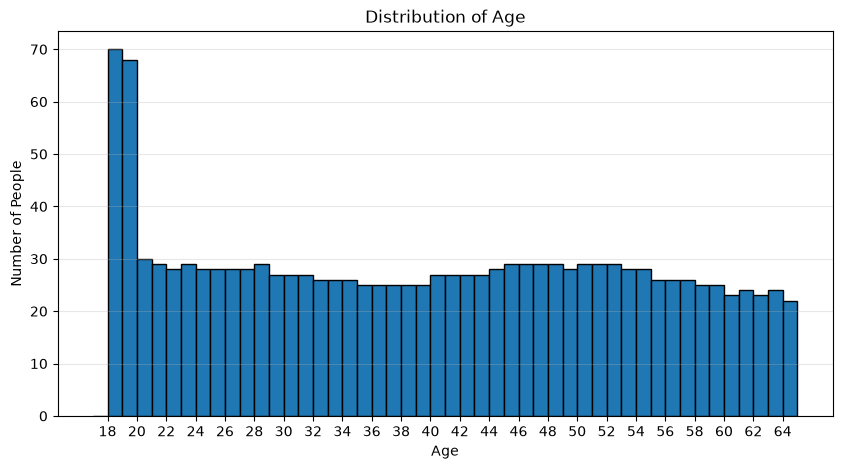

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["age"].dropna(),
    bins=range(17, 66),
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Number of People")
plt.title("Distribution of Age")
plt.xticks(range(18, 65, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### BMI Distribution

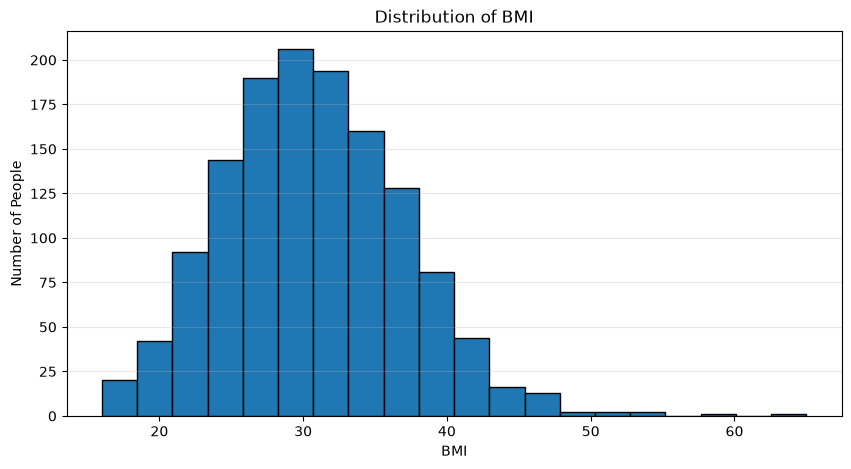

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["bmi"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.xlabel("BMI")
plt.ylabel("Number of People")
plt.title("Distribution of BMI")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Medical Expenses Distribution

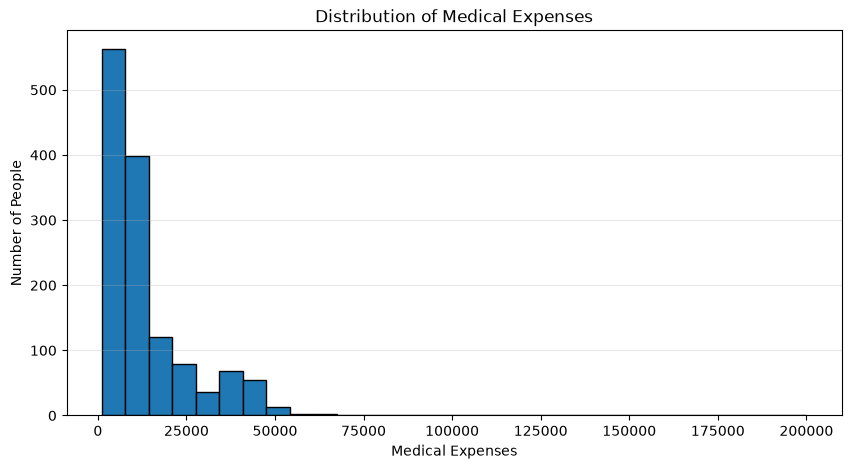

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["expenses"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("Medical Expenses")
plt.ylabel("Number of People")
plt.title("Distribution of Medical Expenses")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Smoker Distribution

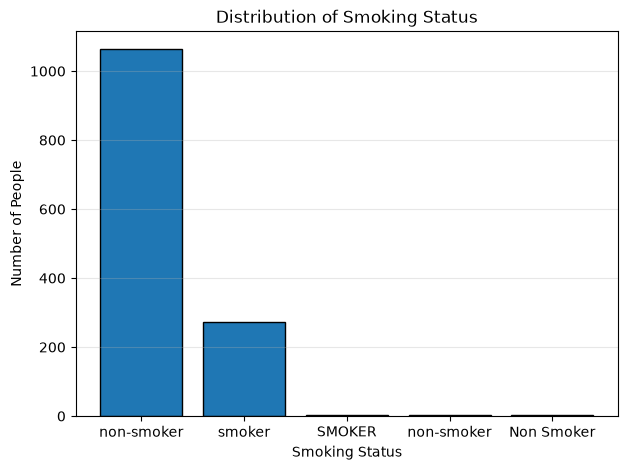

In [31]:
smoker_counts = df["smoker"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(smoker_counts.index, smoker_counts.values, edgecolor="black")

plt.xlabel("Smoking Status")
plt.ylabel("Number of People")
plt.title("Distribution of Smoking Status")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Region Distribution

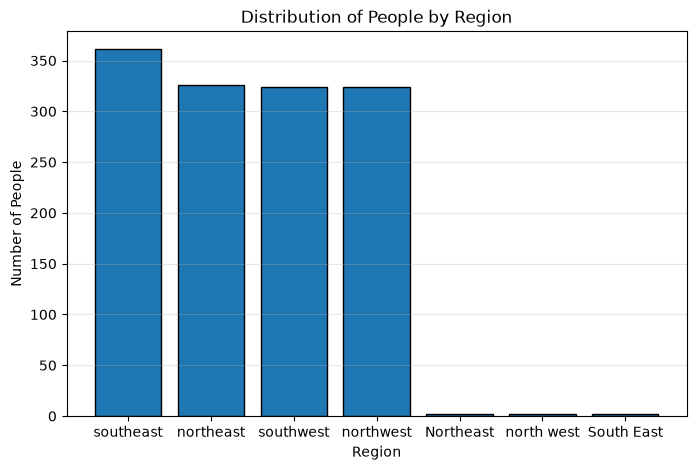

In [32]:
region_counts = df["region"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(region_counts.index, region_counts.values, edgecolor="black")

plt.xlabel("Region")
plt.ylabel("Number of People")
plt.title("Distribution of People by Region")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Gender Distribution

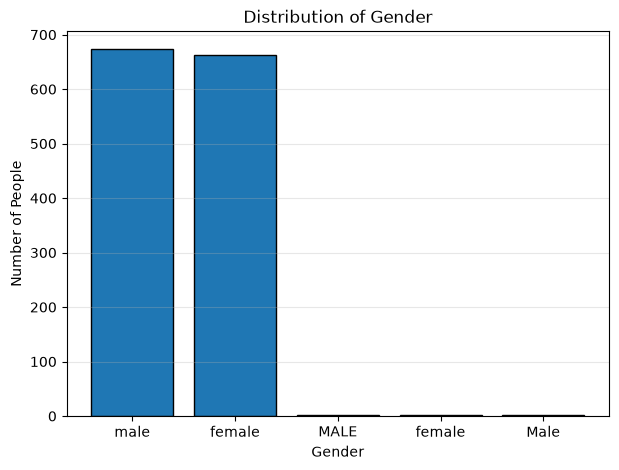

In [33]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index, gender_counts.values, edgecolor="black")

plt.xlabel("Gender")
plt.ylabel("Number of People")
plt.title("Distribution of Gender")
plt.grid(axis="y", alpha=0.3)

plt.show()

### BMI vs Medical Expenses

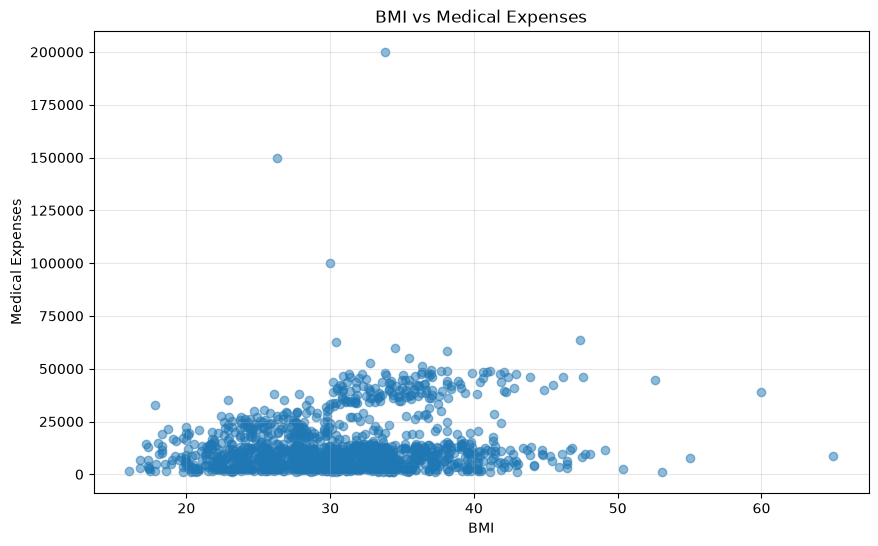

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["bmi"],
    df["expenses"],
    alpha=0.5
)

plt.xlabel("BMI")
plt.ylabel("Medical Expenses")
plt.title("BMI vs Medical Expenses")
plt.grid(alpha=0.3)

plt.show()

A few important observations:
- Most people have BMI between roughly 20 and 40.
- Most expenses are concentrated below around 25,000–30,000.
- There is a noticeable group with higher expenses around 30,000–50,000.
- The extreme points at 100,000, 150,000, and 200,000 are clearly visible. These are the artificial outliers we introduced.
- Some people with similar BMI values have very different medical expenses.

### Smoking Status vs Medical Expenses

<Figure size 800x600 with 0 Axes>

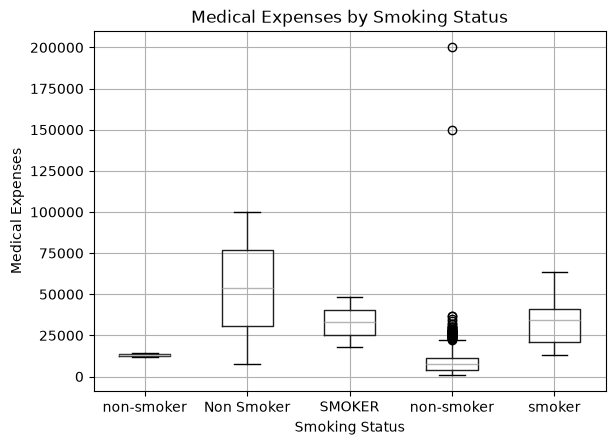

In [35]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="expenses",
    by="smoker"
)

plt.xlabel("Smoking Status")
plt.ylabel("Medical Expenses")
plt.title("Medical Expenses by Smoking Status")
plt.suptitle("")

plt.show()

### Age vs Medical Expenses

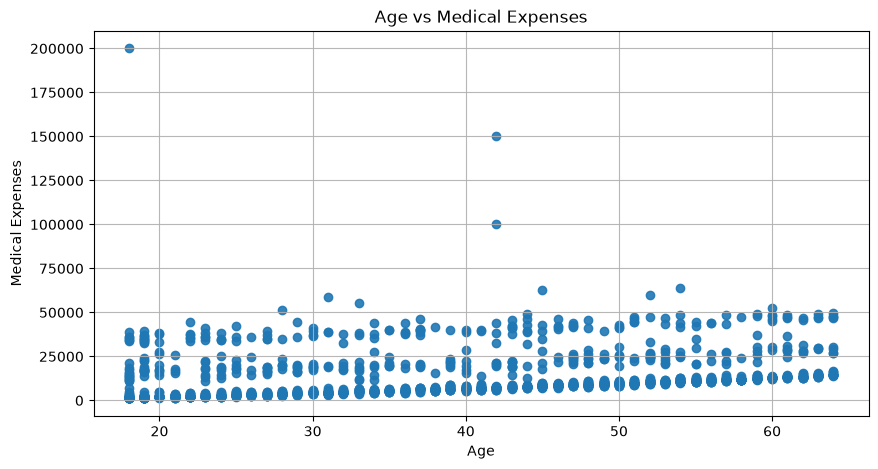

In [44]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["age"],
    df["expenses"],
    alpha=0.9
)

plt.xlabel("Age")
plt.ylabel("Medical Expenses")
plt.title("Age vs Medical Expenses")
plt.grid(alpha=0.9)

plt.show()

What does it tell us?
We can see a general upward relationship between age and medical expenses:
- Younger people generally have lower expenses.
- As age increases, the higher-expense observations become more common.
- However, age alone does not determine expenses. People of the same age can have very different expenses.
- The three extremely high points (100,000, 150,000, 200,000) are clearly visible as outliers.
- There appear to be different expense groups at similar ages, which suggests other features — especially smoking status — may be important.

### Correlation Analysis

In [45]:
numeric_df = df[["age", "bmi", "children", "expenses"]]

correlation = numeric_df.corr()

correlation

,age,bmi,children,expenses
age,1.000000,0.108878,0.041293,0.249150
bmi,0.108878,1.000000,0.018875,0.171088
children,0.041293,0.018875,1.000000,0.054055
expenses,0.249150,0.171088,0.054055,1.000000


### Correlation Heatmap

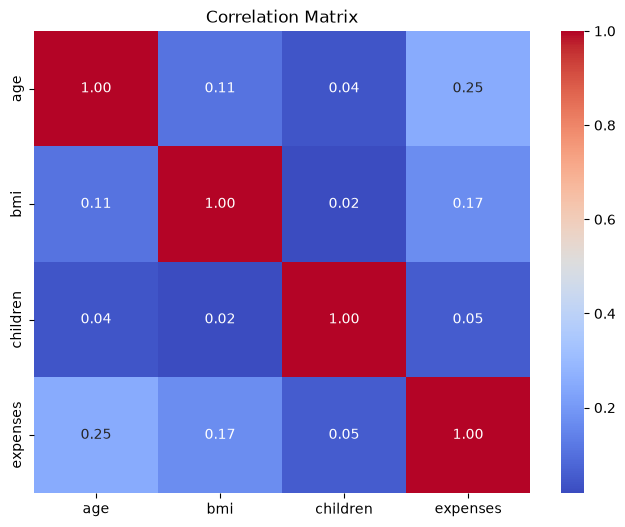

In [47]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Data Preprocessing

### Missing Value Analysis and Fixing

In [48]:
missing_values = df.isnull().sum()

missing_values

age         0
gender      5
bmi         8
children    0
region      5
expenses    5
smoker      5
dtype: int64

In [49]:
df["bmi"].median()

np.float64(30.4)

In [51]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
df["bmi"].isnull().sum()

np.int64(0)

In [54]:
df["gender"].mode()[0]

'male'

In [55]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["gender"].isnull().sum()

np.int64(0)

In [56]:
df["region"].mode()[0]

'southeast'

In [57]:
df["region"] = df["region"].fillna(df["region"].mode()[0])
df["region"].isnull().sum()

np.int64(0)

In [58]:
df["smoker"].mode()[0]

'non-smoker'

In [59]:
df["smoker"] = df["smoker"].fillna(df["smoker"].mode()[0])
df["smoker"].isnull().sum()

np.int64(0)

In [60]:
df["expenses"].isnull().sum()

np.int64(5)

In [61]:
df = df.dropna(subset=["expenses"])
df["expenses"].isnull().sum()

np.int64(0)

In [62]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
region      0
expenses    0
smoker      0
dtype: int64

### Handeling Duplicates

In [63]:
df.duplicated().sum()

np.int64(9)

In [64]:
df = df.drop_duplicates()
df.shape

(1332, 7)

In [65]:
df.duplicated().sum()

np.int64(0)

### Handling Inconsistent categorical values

In [66]:
df["gender"].unique()

<StringArray>
['female', 'male', 'MALE', ' female ', 'Male']
Length: 5, dtype: str

In [67]:
df["gender"] = df["gender"].str.strip().str.lower()

In [68]:
df["gender"].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [69]:
df["region"].unique()

<StringArray>
[  'southwest',   'southeast',   'northwest',   'northeast', ' Northeast ',
  'north west',  'South East']
Length: 7, dtype: str

In [70]:
df["region"].unique()

<StringArray>
[  'southwest',   'southeast',   'northwest',   'northeast', ' Northeast ',
  'north west',  'South East']
Length: 7, dtype: str

In [71]:
df["region"] = df["region"].str.strip().str.lower()
df["region"].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast', 'north west',
 'south east']
Length: 6, dtype: str

In [72]:
df["region"] = df["region"].replace({
    "north west": "northwest",
    "south east": "southeast"
})

In [73]:
df["region"].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [ ]:
df["smoker"].unique()

<StringArray>
['smoker', 'non-smoker', 'SMOKER', ' non-smoker ', 'Non Smoker']
Length: 5, dtype: str

In [75]:
df["smoker"] = (
    df["smoker"]
    .str.strip()
    .str.lower()
    .replace({
        "non smoker": "non-smoker"
    })
)

In [76]:
df["smoker"].unique()

<StringArray>
['smoker', 'non-smoker']
Length: 2, dtype: str

In [77]:
df.info()

<class 'pandas.DataFrame'>
Index: 1332 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1332 non-null   int64  
 1   gender    1332 non-null   str    
 2   bmi       1332 non-null   float64
 3   children  1332 non-null   int64  
 4   region    1332 non-null   str    
 5   expenses  1332 non-null   float64
 6   smoker    1332 non-null   str    
dtypes: float64(2), int64(2), str(3)
memory usage: 83.2 KB


In [78]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 26.3
Q3: 34.725
IQR: 8.425


In [79]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 13.6625
Upper Bound: 47.362500000000004


In [80]:
bmi_outliers = df[
    (df["bmi"] < lower_bound) |
    (df["bmi"] > upper_bound)
]

print("Number of BMI outliers:", len(bmi_outliers))

Number of BMI outliers: 12


In [81]:
bmi_outliers[["age", "bmi", "expenses", "smoker"]].sort_values("bmi")

,age,bmi,expenses,smoker
543,54,47.4,63770.43,smoker
401,47,47.5,8083.92,non-smoker
860,37,47.6,46113.51,smoker
1088,52,47.7,9748.91,non-smoker
286,46,48.1,9432.93,non-smoker
116,58,49.1,11381.33,non-smoker
847,23,50.4,2438.06,non-smoker
1047,22,52.6,44501.40,smoker
1317,18,53.1,1163.46,non-smoker
151,48,55.0,7789.64,non-smoker


In [82]:
df[df["bmi"] > 54][["age", "bmi", "expenses", "smoker"]]

,age,bmi,expenses,smoker
151,48,55.0,7789.64,non-smoker
298,31,60.0,38746.36,smoker
537,46,65.0,8825.09,non-smoker


In [83]:
df = df[df["bmi"] <= 54]

In [84]:
df.shape

(1329, 7)

In [85]:
Q1_exp = df["expenses"].quantile(0.25)
Q3_exp = df["expenses"].quantile(0.75)

IQR_exp = Q3_exp - Q1_exp

print("Q1:", Q1_exp)
print("Q3:", Q3_exp)
print("IQR:", IQR_exp)

Q1: 4746.34
Q3: 16884.92
IQR: 12138.579999999998


In [86]:
lower_exp = Q1_exp - 1.5 * IQR_exp
upper_exp = Q3_exp + 1.5 * IQR_exp

print("Lower Bound:", lower_exp)
print("Upper Bound:", upper_exp)

Lower Bound: -13461.529999999995
Upper Bound: 35092.78999999999


In [88]:
df[df["expenses"] < 0]

,age,gender,bmi,children,region,expenses,smoker


In [87]:
expense_outliers = df[df["expenses"] > upper_exp]

print("Number of expense outliers:", len(expense_outliers))

Number of expense outliers: 134


In [89]:
expense_outliers[["age", "bmi", "expenses", "smoker"]].sort_values(
    "expenses",
    ascending=False
).head(15)

,age,bmi,expenses,smoker
1,18,33.8,200000.00,non-smoker
1310,42,26.3,150000.00,non-smoker
461,42,30.0,100000.00,non-smoker
543,54,47.4,63770.43,smoker
1300,45,30.4,62592.87,smoker
1230,52,34.5,60021.40,smoker
577,31,38.1,58571.07,smoker
819,33,35.5,55135.40,smoker
1146,60,32.8,52590.83,smoker
34,28,36.4,51194.56,smoker


In [90]:
df = df.drop(index=[1, 461, 1310])

In [91]:
df.shape

(1326, 7)

In [93]:
df = df.reset_index(drop=True)
df.index

RangeIndex(start=0, stop=1326, step=1)

In [94]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
region      0
expenses    0
smoker      0
dtype: int64

In [95]:
print("Gender:", df["gender"].unique())
print("Region:", df["region"].unique())
print("Smoker:", df["smoker"].unique())

Gender: <StringArray>
['female', 'male']
Length: 2, dtype: str
Region: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
Smoker: <StringArray>
['smoker', 'non-smoker']
Length: 2, dtype: str


In [96]:
df.to_csv("../data/processed/medical_insurance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


### Split features and target

In [97]:
X = df.drop("expenses", axis=1)
y = df["expenses"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1326, 6)
y shape: (1326,)


In [98]:
print(X.dtypes)

age           int64
gender          str
bmi         float64
children      int64
region          str
smoker          str
dtype: object


### Encode the categorical data

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ["age", "bmi", "children"]
categorical_features = ["gender", "region", "smoker"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


# Data Spliting

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1060, 6)
X_test: (266, 6)
y_train: (1060,)
y_test: (266,)


In [101]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (1060, 11)
Testing data shape: (266, 11)


In [102]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__age' 'num__bmi' 'num__children' 'cat__gender_female'
 'cat__gender_male' 'cat__region_northeast' 'cat__region_northwest'
 'cat__region_southeast' 'cat__region_southwest' 'cat__smoker_non-smoker'
 'cat__smoker_smoker']
